# Weather time series pipeline

Полный ноутбук для разбора Excel-файла, очистки временного ряда, EDA, feature engineering и многошагового прогноза температуры на 1 неделю вперед.

Ключевая идея очистки: сначала найти все листы через `openpyxl`, затем выбрать те, где есть колонка `ds`, и только после этого собрать единый dataframe через `pandas`.

In [2]:
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from scipy import signal
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
import optuna

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

DATA_DIR = Path(r'c:\Users\1\OneDrive\Desktop\Data_Science_lab2')
XLSX_PATH = DATA_DIR / 'have_fun.xlsx'
RAW_CSV = DATA_DIR / 'cleaned_weather.csv'
FINAL_CSV = DATA_DIR / 'weather_panel_canonical.csv'

c:\Users\1\OneDrive\Desktop\Data_Science_lab2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Как были найдены данные в XLSX

Сначала workbook открывается через `openpyxl`, чтобы увидеть все листы, включая скрытые. Затем для каждого листа проверяется наличие колонки `ds`. Листы без временной метки или пустые служебные листы отбрасываются.

Строки `city` были записаны в xlsx как текст, закодированный в cp1251, поэтому их нужно декодировать через трюк `latin-1 -> cp1251`. После этого опечатки и усеченные варианты приводятся к каноническим названиям городов.

In [3]:
CANONICAL_CITIES = [
    "\u0411\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a",
    "\u0413\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a",
    "\u041c\u043e\u0441\u043a\u0432\u0430",
    "\u041d\u0430\u0445\u043e\u0434\u043a\u0430",
    "\u0421\u0430\u043d\u043a\u0442-\u041f\u0435\u0442\u0435\u0440\u0431\u0443\u0440\u0433",
    "\u0421\u043e\u0447\u0438",
]
ALIASES = {
    "\u0431\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441": "\u0411\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a",
    "\u0431\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a\u043a": "\u0411\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a",
    "\u0431\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a": "\u0411\u043b\u0430\u0433\u043e\u0432\u0435\u0449\u0435\u043d\u0441\u043a",
    "\u0433\u0435\u043b\u0435\u043d\u0434\u0436\u0438": "\u0413\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a",
    "\u0433\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a\u043a": "\u0413\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a",
    "\u0433\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a": "\u0413\u0435\u043b\u0435\u043d\u0434\u0436\u0438\u043a",
    "\u043c\u043e\u0441\u0432\u0430": "\u041c\u043e\u0441\u043a\u0432\u0430",
    "\u0441\u043e\u0447": "\u0421\u043e\u0447\u0438",
    "\u0441\u0447\u0438": "\u0421\u043e\u0447\u0438",
    "\u0441\u044b\u0447\u0438": "\u0421\u043e\u0447\u0438",
}
NUMERIC_COLS = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure"]
EXPECTED_COLS = ["ds", "city"] + NUMERIC_COLS


def decode_city(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().strip("\"'")
    try:
        return text.encode("latin-1", errors="backslashreplace").decode("cp1251", errors="replace")
    except Exception:
        return text


def canonicalize_city(value):
    text = decode_city(value)
    key = str(text).casefold().replace("ё", "е").replace(" ", "")
    if key in {"", "nan", "none", "null"}:
        return np.nan
    if key in ALIASES:
        return ALIASES[key]
    ranked = []
    for city in CANONICAL_CITIES:
        score = SequenceMatcher(None, key, city.casefold().replace("ё", "е").replace(" ", "")).ratio()
        ranked.append((score, city))
    score, city = max(ranked)
    return city if score >= 0.55 else str(text).title()


def read_relevant_sheets(xlsx_path):
    workbook = load_workbook(xlsx_path, data_only=False, read_only=True)
    sheet_info = pd.DataFrame([
        {"sheet": ws.title, "state": ws.sheet_state, "rows": ws.max_row, "cols": ws.max_column}
        for ws in workbook.worksheets
    ])
    display(sheet_info)

    parts = []
    for ws in workbook.worksheets:
        frame = pd.read_excel(xlsx_path, sheet_name=ws.title, engine="openpyxl")
        if frame.empty or "ds" not in frame.columns:
            continue
        use_cols = [col for col in EXPECTED_COLS if col in frame.columns]
        frame = frame[use_cols].copy()
        frame["city"] = frame["city"].map(canonicalize_city)
        frame["ds"] = pd.to_datetime(frame["ds"], errors="coerce")
        for col in NUMERIC_COLS:
            if col in frame.columns:
                frame[col] = pd.to_numeric(frame[col], errors="coerce")
        parts.append(frame)

    raw = pd.concat(parts, ignore_index=True)
    raw = raw.dropna(subset=["ds", "city"]).sort_values(["city", "ds"]).drop_duplicates(["city", "ds"]).reset_index(drop=True)
    return raw


raw_df = read_relevant_sheets(XLSX_PATH)
raw_df.to_csv(FINAL_CSV, index=False)
print(raw_df.shape)
print(raw_df["city"].value_counts())

,sheet,state,rows,cols
0,Ëèñò1,visible,125125,10
1,Лист1,visible,1,1
2,ÌÀÈ,visible,1000,1
3,ýòî,visible,1000,1
4,ÿ,visible,1000,1
5,!,visible,1000,1
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,hidden,125170,25
7,Ëèñò3_ñìåøàííûå_òèïû,hidden,122737,10


(368090, 10)
city
Санкт-Петербург    61368
Сочи               61368
Москва             61364
Геленджик          61337
Благовещенск       61336
Находка            61317
Name: count, dtype: int64


## Предварительный анализ и диагностика
В этом разделе на основе очищенных ежечасных данных создается ежедневная панель и выполняются основные этапы EDA.

main cities: ['\\u0421\\u0430\\u043d\\u043a\\u0442-\\u041f\\u0435\\u0442\\u0435\\u0440\\u0431\\u0443\\u0440\\u0433', '\\u0421\\u043e\\u0447\\u0438', '\\u041c\\u043e\\u0441\\u043a\\u0432\\u0430', '\\u0413\\u0435\\u043b\\u0435\\u043d\\u0434\\u0436\\u0438\\u043a', '\\u0411\\u043b\\u0430\\u0433\\u043e\\u0432\\u0435\\u0449\\u0435\\u043d\\u0441\\u043a', '\\u041d\\u0430\\u0445\\u043e\\u0434\\u043a\\u0430']
hourly shape: (368090, 10)
date range: 2019-01-01 00:00:00 2025-12-31 23:00:00
missing values:
 ds                         0
city                       0
temperature_2m          4289
relative_humidity_2m       5
precipitation           3681
rain                       0
snowfall                   0
weathercode             1841
wind_speed_10m          3064
surface_pressure           0
dtype: int64


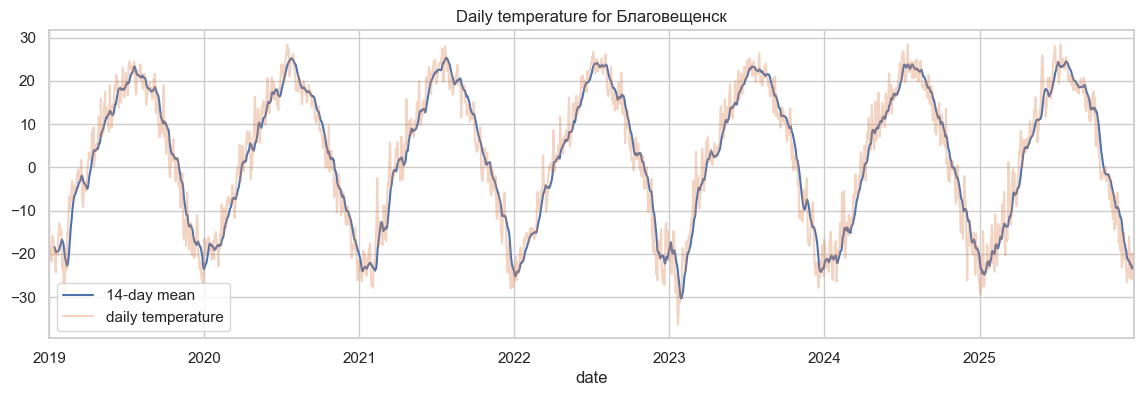

{'adf_stat': np.float64(-3.329127234969461), 'p_value': np.float64(0.013625640876481057)}


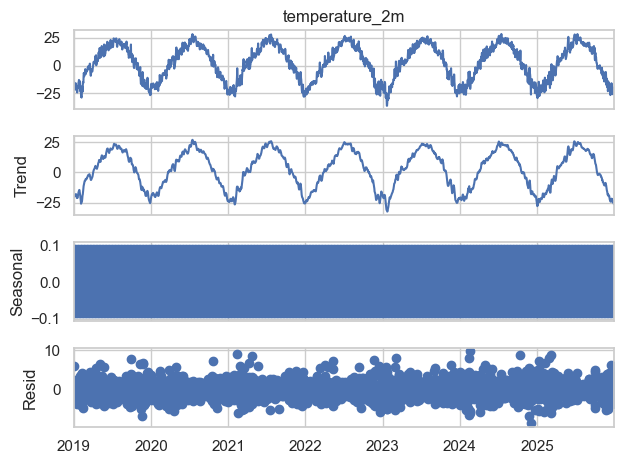

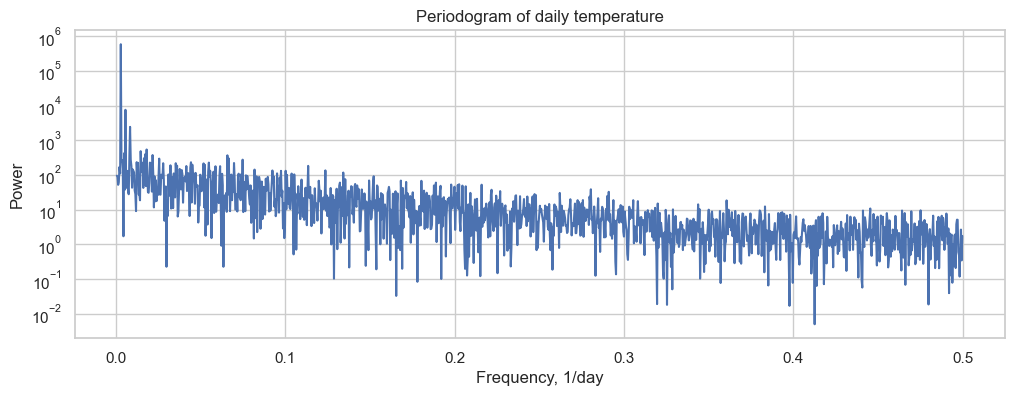

                 count       mean        std        min        max
city                                                              
Благовещенск      2557   2.209667  15.603194 -36.287500  28.456522
Геленджик         2557  14.360065   8.161162  -7.325000  32.654167
Москва            2557   6.908183  10.216586 -27.941667  27.983333
Находка           2557   7.046041  11.154719 -23.545833  28.227938
Санкт-Петербург   2557   6.790766   9.339273 -27.412500  29.291667
Сочи              2557  15.042392   7.055891  -4.195652  29.554167


In [5]:
hourly_df = raw_df.copy()
hourly_df['ds'] = pd.to_datetime(hourly_df['ds'])
hourly_df = hourly_df.sort_values(['city', 'ds']).reset_index(drop=True)

city_counts = hourly_df['city'].value_counts()
main_cities = city_counts[city_counts >= 1000].index.tolist()
print('main cities:', [city.encode('unicode_escape').decode('ascii') for city in main_cities])

analysis_hourly = hourly_df[hourly_df['city'].isin(main_cities)].copy()
analysis_hourly.to_csv(DATA_DIR / 'weather_hourly_main_cities.csv', index=False)

print('hourly shape:', analysis_hourly.shape)
print('date range:', analysis_hourly['ds'].min(), analysis_hourly['ds'].max())
print('missing values:\n', analysis_hourly.isna().sum())

analysis_daily = (
    analysis_hourly.assign(date=analysis_hourly['ds'].dt.floor('D'))
    .groupby(['city', 'date'], as_index=False)
    .agg(temperature_2m=('temperature_2m', 'mean'))
    .sort_values(['city', 'date'])
    .reset_index(drop=True)
)
analysis_daily.to_csv(DATA_DIR / 'weather_daily_main_cities.csv', index=False)

sample_city = analysis_daily['city'].value_counts().idxmax()
city_daily = analysis_daily[analysis_daily['city'] == sample_city].copy().sort_values('date')
series = city_daily.set_index('date')['temperature_2m'].asfreq('D').interpolate('time')

fig, ax = plt.subplots(figsize=(14, 4))
series.rolling(14).mean().plot(ax=ax, label='14-day mean')
series.plot(ax=ax, alpha=0.35, label='daily temperature')
ax.set_title(f'Daily temperature for {sample_city}')
ax.legend()
plt.show()

adf_stat, adf_pvalue, *_ = adfuller(series.dropna())
print({'adf_stat': adf_stat, 'p_value': adf_pvalue})

period = 7 if len(series) >= 21 else max(2, len(series) // 3)
decomposition = seasonal_decompose(series, model='additive', period=period, extrapolate_trend='freq')
decomposition.plot(); plt.show()

freqs, power = signal.periodogram(series.values, fs=1.0)
plt.figure(figsize=(12, 4))
plt.semilogy(freqs[1:], power[1:])
plt.title('Periodogram of daily temperature')
plt.xlabel('Frequency, 1/day')
plt.ylabel('Power')
plt.show()

city_summary = analysis_daily.groupby('city')['temperature_2m'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values('count', ascending=False)
print(city_summary)


## Feature engineering and forecasting strategies

Здесь строится дневная панель признаков, затем сравниваются две стратегии:

- recursive: одна модель делает шаг на 1 день вперед и используется итеративно 7 раз;
- direct multi-horizon: отдельная модель обучается для каждого горизонта от 1 до 7 дней.

Для прогноза используются только признаки, доступные на момент предсказания: календарь, лаги и скользящие статистики температуры.

date split sizes: 1789 383 384

Tuning tree for 1-day horizon
best params: {'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 4}

Tuning rf for 1-day horizon
best params: {'n_estimators': 168, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 0.9047901878737659}

Tuning hgb for 1-day horizon
best params: {'learning_rate': 0.024168044164928012, 'max_depth': 9, 'max_leaf_nodes': 44, 'min_samples_leaf': 28, 'max_iter': 179}
   model   strategy  horizon     n        MAE      WAPE      MAPE  directional_accuracy  directional_r2
16   hgb     direct        1  2304   2.445447  0.203092  1.255333              0.446374       -0.405124
17   hgb     direct        2  2304   2.688028  0.223238  1.488766              0.485888       -0.175296
18   hgb     direct        3  2304   2.854611  0.237072  1.832520              0.503691       -0.065330
19   hgb     direct        4  2304   2.961325  0.245935  1.735910              0.505428       -0.063889
20   hgb     direct        5  2304   3.0

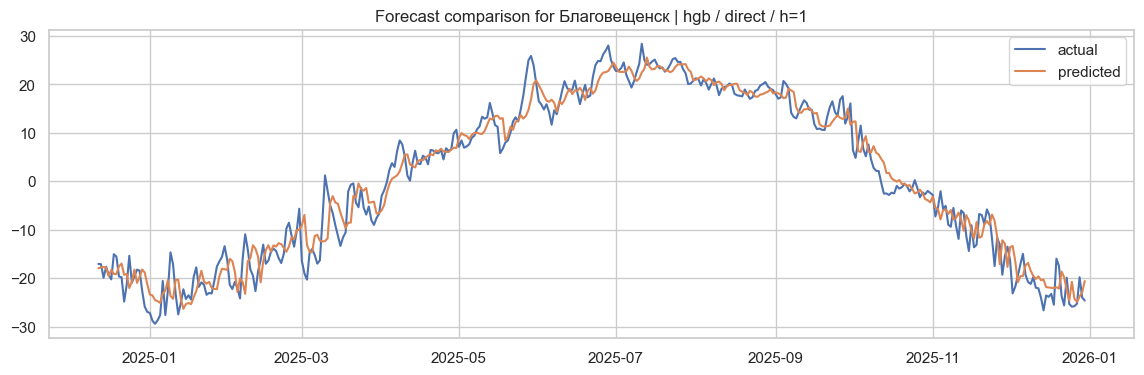

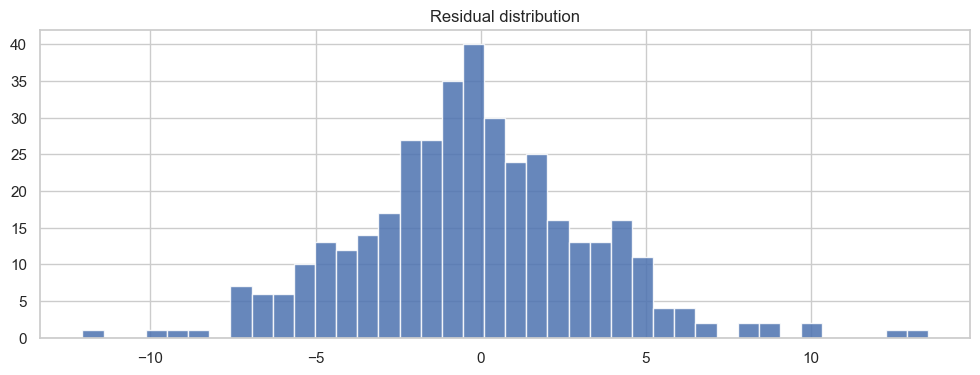

        MAE      WAPE      MAPE  directional_accuracy  directional_r2             city     n
0  2.675842  0.179165  0.506097              0.430809       -0.645424     Благовещенск   384
1  2.294760  0.166718  1.414654              0.475196       -0.440845        Геленджик   384
2  2.916820  0.309604  2.818779              0.443864       -0.596395           Москва   384
3  2.382027  0.209297  0.729880              0.485640       -0.358840          Находка   384
4  2.442582  0.285502  1.735403              0.409922       -0.566119  Санкт-Петербург   384
5  1.960649  0.138176  0.327184              0.425587       -0.568279             Сочи   384
6  2.445447  0.203092  1.255333              0.446374       -0.405124              ALL  2304


In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

DAILY = analysis_daily.copy()
DAILY['date'] = pd.to_datetime(DAILY['date'])
DAILY = DAILY.sort_values(['city', 'date']).reset_index(drop=True)

LAGS = [1, 2, 3, 7, 14, 28]
ROLL_WINDOWS = [3, 7, 14]
HORIZONS = [1, 2, 3, 4, 5, 6, 7]


def add_daily_features(frame):
    frame = frame.sort_values(['city', 'date']).copy()
    pieces = []
    for city, group in frame.groupby('city'):
        group = group.sort_values('date').copy()
        group['dow'] = group['date'].dt.dayofweek
        group['month'] = group['date'].dt.month
        group['doy'] = group['date'].dt.dayofyear
        group['is_weekend'] = (group['dow'] >= 5).astype(int)
        group['dow_sin'] = np.sin(2 * np.pi * group['dow'] / 7)
        group['dow_cos'] = np.cos(2 * np.pi * group['dow'] / 7)
        group['month_sin'] = np.sin(2 * np.pi * group['month'] / 12)
        group['month_cos'] = np.cos(2 * np.pi * group['month'] / 12)
        group['year'] = group['date'].dt.year
        for lag in LAGS:
            group[f'temp_lag_{lag}'] = group['temperature_2m'].shift(lag)
        for window in ROLL_WINDOWS:
            shifted = group['temperature_2m'].shift(1)
            group[f'temp_roll_mean_{window}'] = shifted.rolling(window).mean()
            group[f'temp_roll_std_{window}'] = shifted.rolling(window).std()
        for horizon in HORIZONS:
            group[f'target_{horizon}'] = group['temperature_2m'].shift(-horizon)
            group[f'target_date_{horizon}'] = group['date'] + pd.to_timedelta(horizon, unit='D')
        pieces.append(group)
    return pd.concat(pieces, ignore_index=True)


def date_split_masks(frame, train_frac=0.7, val_frac=0.15):
    dates = np.array(sorted(frame['date'].unique()))
    train_end = int(len(dates) * train_frac)
    val_end = int(len(dates) * (train_frac + val_frac))
    train_dates = pd.Index(dates[:train_end])
    val_dates = pd.Index(dates[train_end:val_end])
    test_dates = pd.Index(dates[val_end:])
    return train_dates, val_dates, test_dates


def make_pipeline(model_name, params, feature_cols):
    categorical_cols = ['city']
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
            ('num', SimpleImputer(strategy='median'), numeric_cols),
        ]
    )
    if model_name == 'tree':
        model = DecisionTreeRegressor(random_state=42, **params)
    elif model_name == 'rf':
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    elif model_name == 'hgb':
        model = HistGradientBoostingRegressor(random_state=42, **params)
    else:
        raise ValueError(model_name)
    return Pipeline([('preprocess', preprocessor), ('model', model)])


def model_param_space(trial, model_name):
    if model_name == 'tree':
        return {
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'rf':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 80, 220),
            'max_depth': trial.suggest_int('max_depth', 4, 18),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_float('max_features', 0.4, 1.0),
        }
    if model_name == 'hgb':
        return {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 40),
            'max_iter': trial.suggest_int('max_iter', 100, 250),
        }
    raise ValueError(model_name)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), 1e-8)
    if len(y_true) > 1:
        true_diff = np.diff(y_true)
        pred_diff = np.diff(y_pred)
        directional_accuracy = np.mean(np.sign(true_diff) == np.sign(pred_diff))
        directional_r2 = r2_score(true_diff, pred_diff)
    else:
        directional_accuracy = np.nan
        directional_r2 = np.nan
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'WAPE': np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / denom)),
        'directional_accuracy': directional_accuracy,
        'directional_r2': directional_r2,
    }


def tune_model(frame, target_col, target_date_col, model_name, train_dates, val_dates, feature_cols, n_trials=5):
    train_frame = frame[frame[target_date_col].isin(train_dates)].copy()
    val_frame = frame[frame[target_date_col].isin(val_dates)].copy()
    train_frame = train_frame.dropna(subset=feature_cols + [target_col])
    val_frame = val_frame.dropna(subset=feature_cols + [target_col])

    def objective(trial):
        params = model_param_space(trial, model_name)
        pipe = make_pipeline(model_name, params, feature_cols)
        pipe.fit(train_frame[feature_cols], train_frame[target_col])
        pred = pipe.predict(val_frame[feature_cols])
        return mean_absolute_error(val_frame[target_col], pred)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def fit_model(frame, target_col, target_date_col, model_name, params, fit_dates, feature_cols):
    fit_frame = frame[frame[target_date_col].isin(fit_dates)].copy()
    fit_frame = fit_frame.dropna(subset=feature_cols + [target_col])
    pipe = make_pipeline(model_name, params, feature_cols)
    pipe.fit(fit_frame[feature_cols], fit_frame[target_col])
    return pipe


def evaluate_direct(frame, target_col, target_date_col, model, test_dates, feature_cols, horizon):
    test_frame = frame[frame[target_date_col].isin(test_dates)].copy()
    test_frame = test_frame.dropna(subset=feature_cols + [target_col])
    pred = model.predict(test_frame[feature_cols])
    out = test_frame[['city', 'date', target_col]].copy()
    out = out.rename(columns={target_col: 'actual'})
    out['pred'] = pred
    out['horizon'] = horizon
    out = out.rename(columns={'date': 'forecast_origin'})
    out['forecast_date'] = test_frame[target_date_col].values
    return out


def recursive_forecast(frame, model, train_dates, test_dates, feature_cols):
    forecast_start = pd.Index(test_dates).min()
    forecast_end = pd.Index(test_dates).max()
    history_end = forecast_start - pd.Timedelta(days=1)
    forecast_dates = pd.date_range(forecast_start, forecast_end, freq='D')
    predictions = []

    for city, group in frame.groupby('city'):
        history = group[group['date'] <= history_end].sort_values('date').copy()
        history_series = history.set_index('date')['temperature_2m'].astype(float).to_dict()

        for forecast_date in forecast_dates:
            row = {
                'city': city,
                'date': forecast_date,
                'dow': forecast_date.dayofweek,
                'month': forecast_date.month,
                'doy': forecast_date.dayofyear,
                'is_weekend': int(forecast_date.dayofweek >= 5),
                'dow_sin': np.sin(2 * np.pi * forecast_date.dayofweek / 7),
                'dow_cos': np.cos(2 * np.pi * forecast_date.dayofweek / 7),
                'month_sin': np.sin(2 * np.pi * forecast_date.month / 12),
                'month_cos': np.cos(2 * np.pi * forecast_date.month / 12),
                'year': forecast_date.year,
            }
            for lag in LAGS:
                row[f'temp_lag_{lag}'] = history_series.get(forecast_date - pd.Timedelta(days=lag), np.nan)
            for window in ROLL_WINDOWS:
                values = [history_series.get(forecast_date - pd.Timedelta(days=i), np.nan) for i in range(1, window + 1)]
                valid = [value for value in values if pd.notna(value)]
                row[f'temp_roll_mean_{window}'] = float(np.mean(valid)) if valid else np.nan
                row[f'temp_roll_std_{window}'] = float(np.std(valid, ddof=1)) if len(valid) > 1 else np.nan
            x = pd.DataFrame([row])[feature_cols]
            yhat = float(model.predict(x)[0])
            history_series[forecast_date] = yhat
            predictions.append({'city': city, 'date': forecast_date, 'pred': yhat})

    pred_frame = pd.DataFrame(predictions)
    actual_frame = frame[frame['date'].isin(forecast_dates)][['city', 'date', 'temperature_2m']].copy()
    actual_frame = actual_frame.rename(columns={'temperature_2m': 'actual'})
    result = actual_frame.merge(pred_frame, on=['city', 'date'], how='inner')
    result['horizon'] = (result['date'] - forecast_start).dt.days + 1
    result['forecast_origin'] = result['date']
    result['forecast_date'] = result['date']
    return result


def summarize_predictions(pred_frame):
    rows = []
    for city, group in pred_frame.sort_values(['city', 'date']).groupby('city'):
        metrics = regression_metrics(group['actual'], group['pred'])
        metrics['city'] = city
        metrics['n'] = len(group)
        rows.append(metrics)
    summary = pd.DataFrame(rows)
    overall = regression_metrics(pred_frame['actual'], pred_frame['pred'])
    overall['city'] = 'ALL'
    overall['n'] = len(pred_frame)
    return pd.concat([summary, pd.DataFrame([overall])], ignore_index=True)


FEATURED_DAILY = add_daily_features(DAILY)
FEATURED_DAILY = FEATURED_DAILY.dropna(subset=['target_1'])
FEATURE_COLS = ['city', 'dow', 'month', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'year'] + [f'temp_lag_{lag}' for lag in LAGS] + [f'temp_roll_mean_{w}' for w in ROLL_WINDOWS] + [f'temp_roll_std_{w}' for w in ROLL_WINDOWS]

train_dates, val_dates, test_dates = date_split_masks(FEATURED_DAILY)
print('date split sizes:', len(train_dates), len(val_dates), len(test_dates))

results = []
forecast_tables = []

for model_name in ['tree', 'rf', 'hgb']:
    print(f'\nTuning {model_name} for 1-day horizon')
    best_params = tune_model(FEATURED_DAILY, 'target_1', 'target_date_1', model_name, train_dates, val_dates, FEATURE_COLS, n_trials=5)
    print('best params:', best_params)

    direct_tables = []
    for horizon in HORIZONS:
        target_col = f'target_{horizon}'
        target_date_col = f'target_date_{horizon}'
        direct_model = fit_model(FEATURED_DAILY, target_col, target_date_col, model_name, best_params, train_dates.union(val_dates), FEATURE_COLS)
        direct_pred = evaluate_direct(FEATURED_DAILY, target_col, target_date_col, direct_model, test_dates, FEATURE_COLS, horizon)
        direct_tables.append(direct_pred)
        metrics = regression_metrics(direct_pred['actual'], direct_pred['pred'])
        metrics['model'] = model_name
        metrics['strategy'] = 'direct'
        metrics['horizon'] = horizon
        metrics['n'] = len(direct_pred)
        results.append(metrics)

    direct_all = pd.concat(direct_tables, ignore_index=True)
    forecast_tables.append(direct_all.assign(model=model_name, strategy='direct'))

    recursive_model = fit_model(FEATURED_DAILY, 'target_1', 'target_date_1', model_name, best_params, train_dates.union(val_dates), FEATURE_COLS)
    recursive_pred = recursive_forecast(FEATURED_DAILY, recursive_model, train_dates.union(val_dates), test_dates, FEATURE_COLS)
    recursive_metrics = regression_metrics(recursive_pred['actual'], recursive_pred['pred'])
    recursive_metrics['model'] = model_name
    recursive_metrics['strategy'] = 'recursive'
    recursive_metrics['horizon'] = 7
    recursive_metrics['n'] = len(recursive_pred)
    results.append(recursive_metrics)
    forecast_tables.append(recursive_pred.assign(model=model_name, strategy='recursive'))

results_df = pd.DataFrame(results)
results_df = results_df[['model', 'strategy', 'horizon', 'n', 'MAE', 'WAPE', 'MAPE', 'directional_accuracy', 'directional_r2']].sort_values(['model', 'strategy', 'horizon'])
print(results_df)

all_forecasts = pd.concat(forecast_tables, ignore_index=True)
all_forecasts.to_csv(DATA_DIR / 'model_forecasts.csv', index=False)
results_df.to_csv(DATA_DIR / 'model_metrics_summary.csv', index=False)

best_row = results_df.sort_values(['MAE']).iloc[0]
print('best row:', best_row.to_dict())

best_key = (all_forecasts['model'] == best_row['model']) & (all_forecasts['strategy'] == best_row['strategy']) & (all_forecasts['horizon'] == best_row['horizon'])
best_forecast = all_forecasts[best_key].copy()
plot_date_col = 'forecast_date' if best_row['strategy'] == 'direct' else 'date'
best_city = best_forecast['city'].value_counts().idxmax()
city_best = best_forecast[best_forecast['city'] == best_city].sort_values(plot_date_col)
residuals = city_best['actual'] - city_best['pred']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(city_best[plot_date_col], city_best['actual'], label='actual')
ax.plot(city_best[plot_date_col], city_best['pred'], label='predicted')
ax.set_title(f'Forecast comparison for {best_city} | {best_row["model"]} / {best_row["strategy"]} / h={best_row["horizon"]}')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(residuals, bins=40, alpha=0.85)
ax.set_title('Residual distribution')
plt.show()

print(summarize_predictions(best_forecast))

In [7]:
print(series.isna().sum(), len(series))
print(series.head(10))

0 2557
date
2019-01-01   -14.037500
2019-01-02   -18.391667
2019-01-03   -18.586957
2019-01-04   -20.756522
2019-01-05   -19.866667
2019-01-06   -19.300000
2019-01-07   -21.760870
2019-01-08   -18.850000
2019-01-09   -15.887500
2019-01-10   -16.113043
Freq: D, Name: temperature_2m, dtype: float64
